In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def processSignals(ref, echo, burst_len):
    signal_ratio = echo*np.conjugate(ref);
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(128)
    s = np.fft.ifft(s)
    return freq_response, s

262144
262144


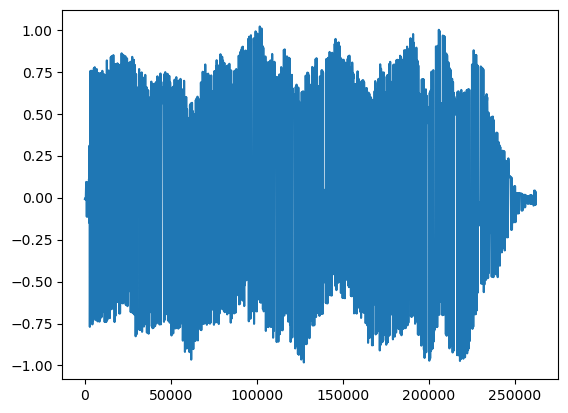

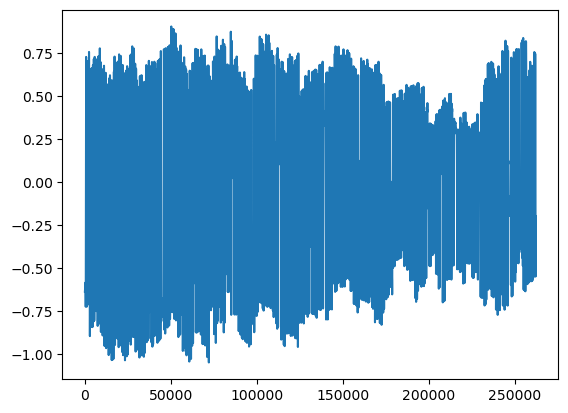

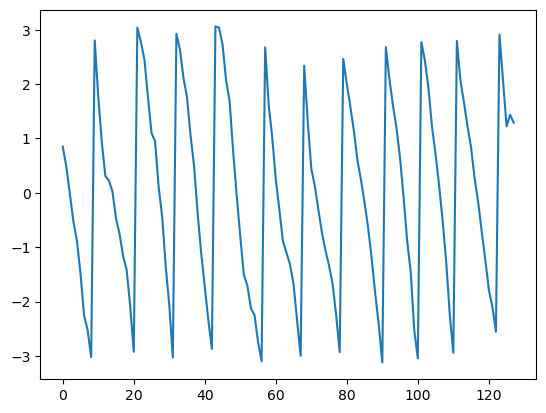

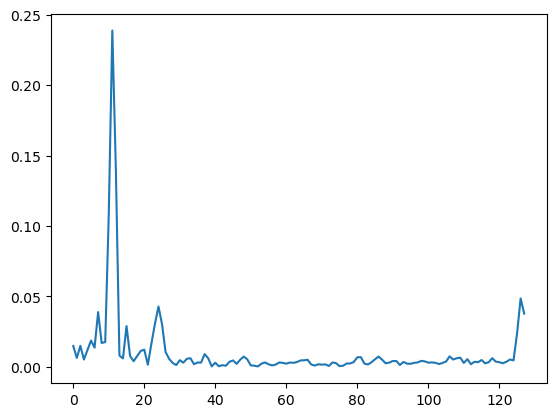

In [313]:
burst_len = 2048
scan_dir = '../gui/'
# cal_samples_list = []
# cal_ref_list = []
# for i in range(2):
#     fileName = 'file_rx_' + str(i) + '.dat'
#     tmp = np.fromfile(fileName, np.complex64) # Read in file.  We have to tell it what format it is
#     cal_samples_list.append(tmp)
# cal_samples = np.mean(np.stack(cal_samples_list),axis=0)
fileName = scan_dir+'scan_raw_rx_10.dat'
cal_samples = np.fromfile(fileName, np.complex64) # Read in file.  We have to tell it what format it is
print(cal_samples.size)
plt.plot(np.real(cal_samples))

fileName = scan_dir+'scan_raw_ref_10.dat'
plt.figure()
cal_ref = np.fromfile(fileName, np.complex64)
print(cal_ref.size)
plt.plot(np.real(cal_ref))

f_cal,s_cal = processSignals(cal_ref, cal_samples, burst_len)

plt.figure()
plt.plot(np.angle(f_cal))

plt.figure()
#plt.plot(10*np.log10(np.abs(s)))
plt.plot((np.abs(s_cal)))

In [314]:
# rx_samples = np.fromfile('../gui/scan_raw_rx_20.dat', np.complex64) # Read in file.  We have to tell it what format it is
# print(rx_samples.size)
# plt.plot(np.abs(rx_samples[0:4096]))

# plt.figure()
# ref_samples = np.fromfile('../gui/scan_raw_ref_20.dat', np.complex64) # Read in file.  We have to tell it what format it is
# print(ref_samples.size)
# plt.plot(np.abs(ref_samples[0:4096]))

# plt.figure()
# calibreated = rx_samples-cal_samples
# plt.plot(np.abs(calibreated[0:4096]))
# f_calbrated,s_calbrated = processSignals(ref_samples,calibreated,burst_len)
# f_rx,s_rx = processSignals(ref_samples,rx_samples,burst_len)

In [315]:
# plt.plot(np.angle(f_rx),color='green')
# plt.plot(np.angle(f_calbrated))
# plt.figure()
# # plt.plot(10*np.log10(np.abs(s)),color = 'green')
# # plt.plot(10*np.log10(np.abs(s_calbrated)))
# plt.plot((np.abs(s_rx)),color = 'green')
# plt.plot((np.abs(s_calbrated)))

# f_calibrated = f_rx-f_cal
# s = f_calibrated
# s = np.fft.ifft(s)
# plt.plot(np.abs(s))

In [317]:
s_list = []
s_cal_list = []
s_cal_list_2 = []
for i in range(132):
    print(i)
    fileName_rx = scan_dir + 'scan_raw_rx_'+str(i)+'.dat'
    fileName_ref = scan_dir + 'scan_raw_ref_'+str(i)+'.dat'
    rx_samples = np.fromfile(fileName_rx, np.complex64) # Read in file.  We have to tell it what format it is
    ref_samples = np.fromfile(fileName_ref, np.complex64) # Read in file.  We have to tell it what format it is
    #rx_samples = rx_samples/cal_samples
    f_rx,s_rx = processSignals(ref_samples,rx_samples,burst_len)
    s_list.append(s_rx)
    f_calibrated = f_rx-f_cal
    s = f_calibrated
    s = np.fft.ifft(s)
    s_cal_list.append(s)
    s_cal_list_2.append(s-s_cal)
s_np = np.stack(s_list, axis=0)
s_cal_np = np.stack(s_cal_list, axis = 0)
s_cal_np_2 =  np.stack(s_cal_list_2, axis = 0)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131


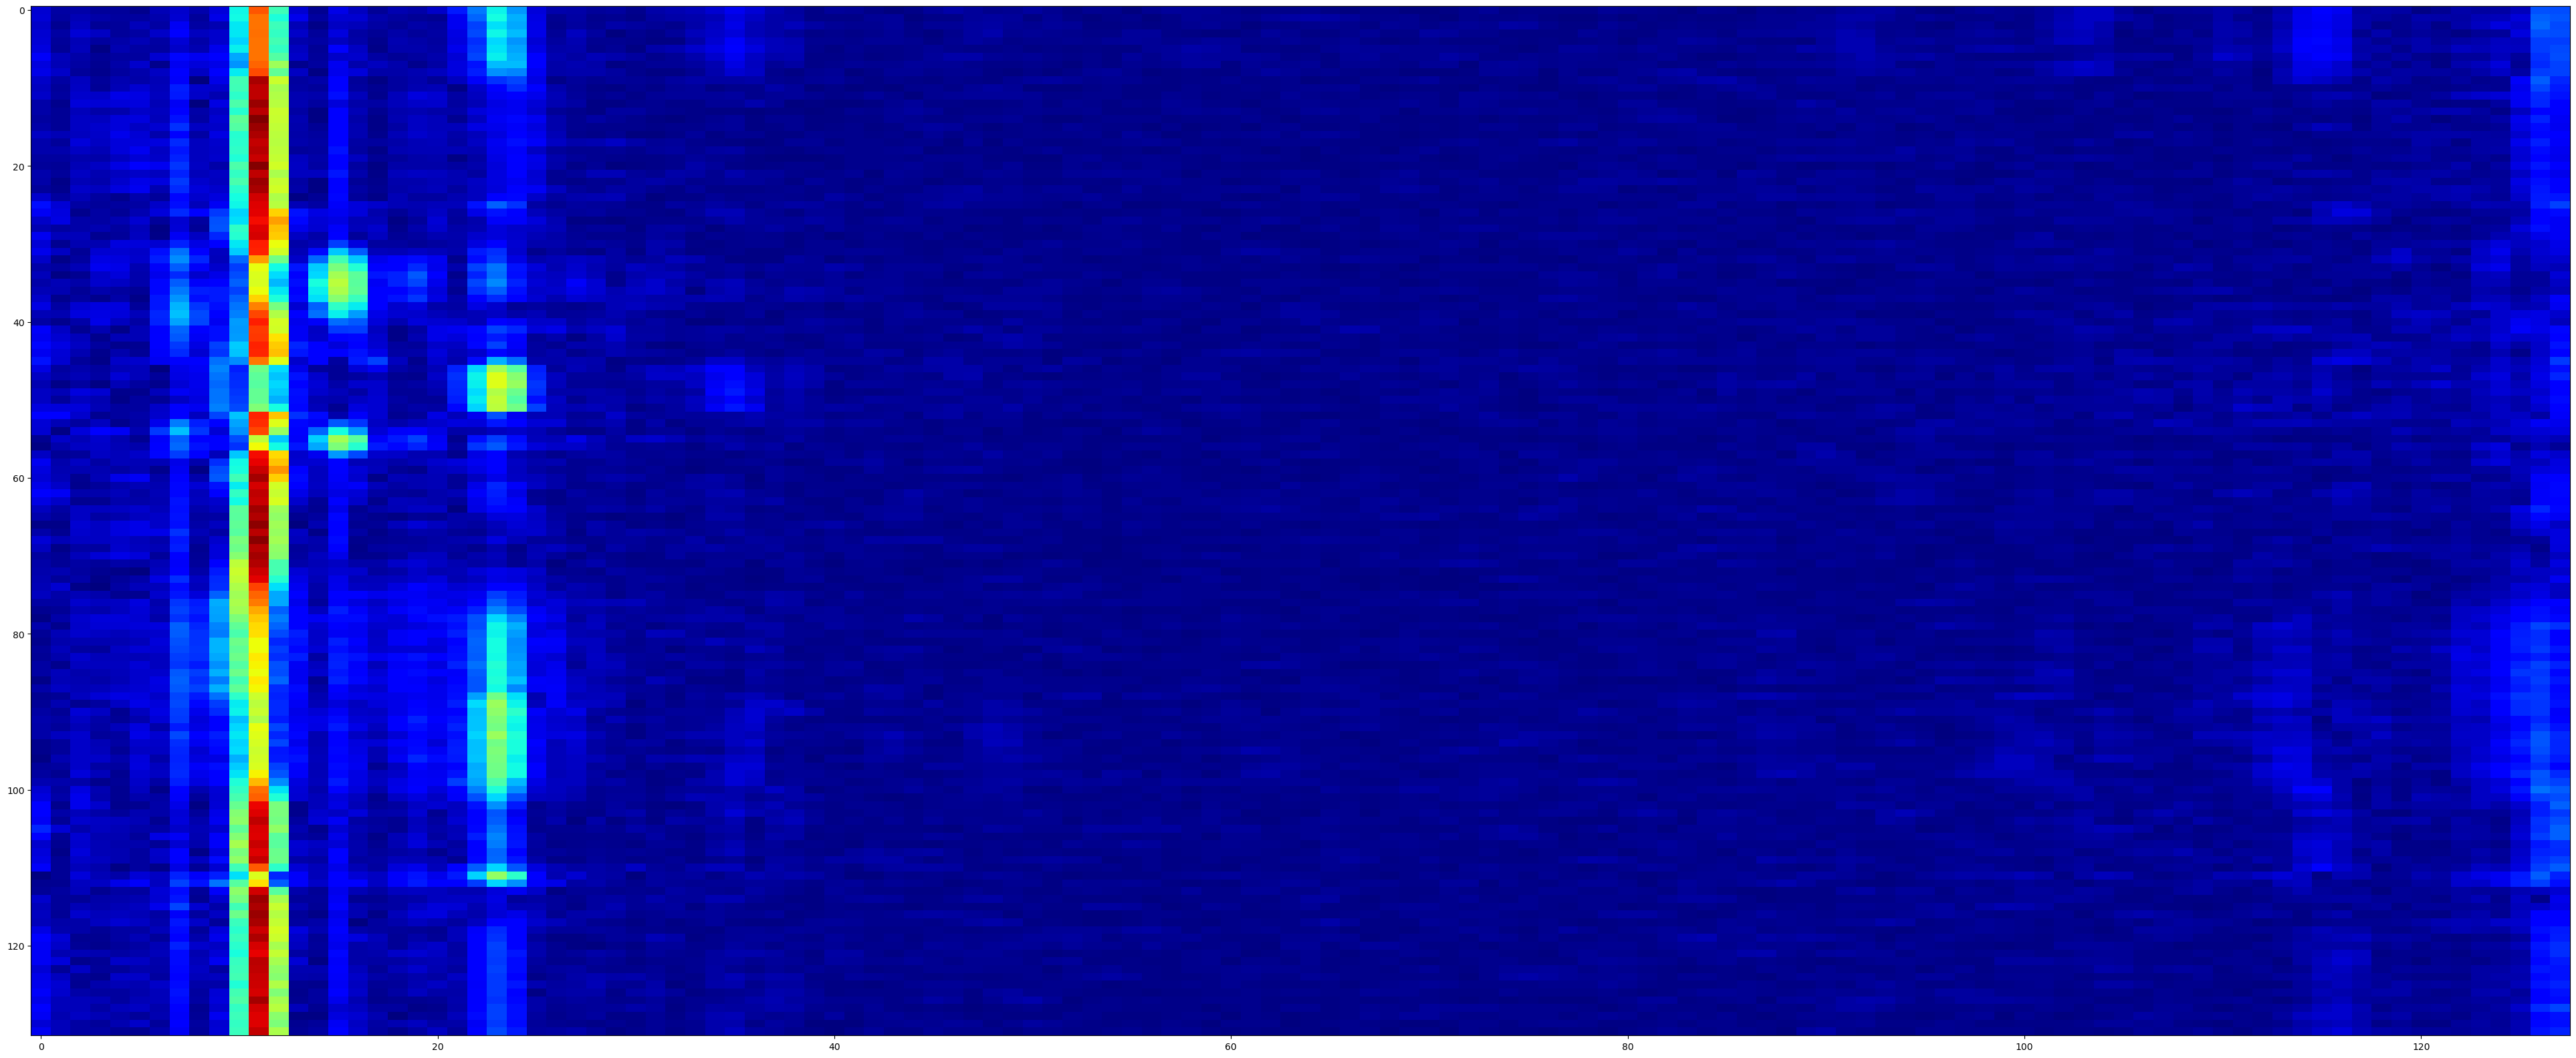

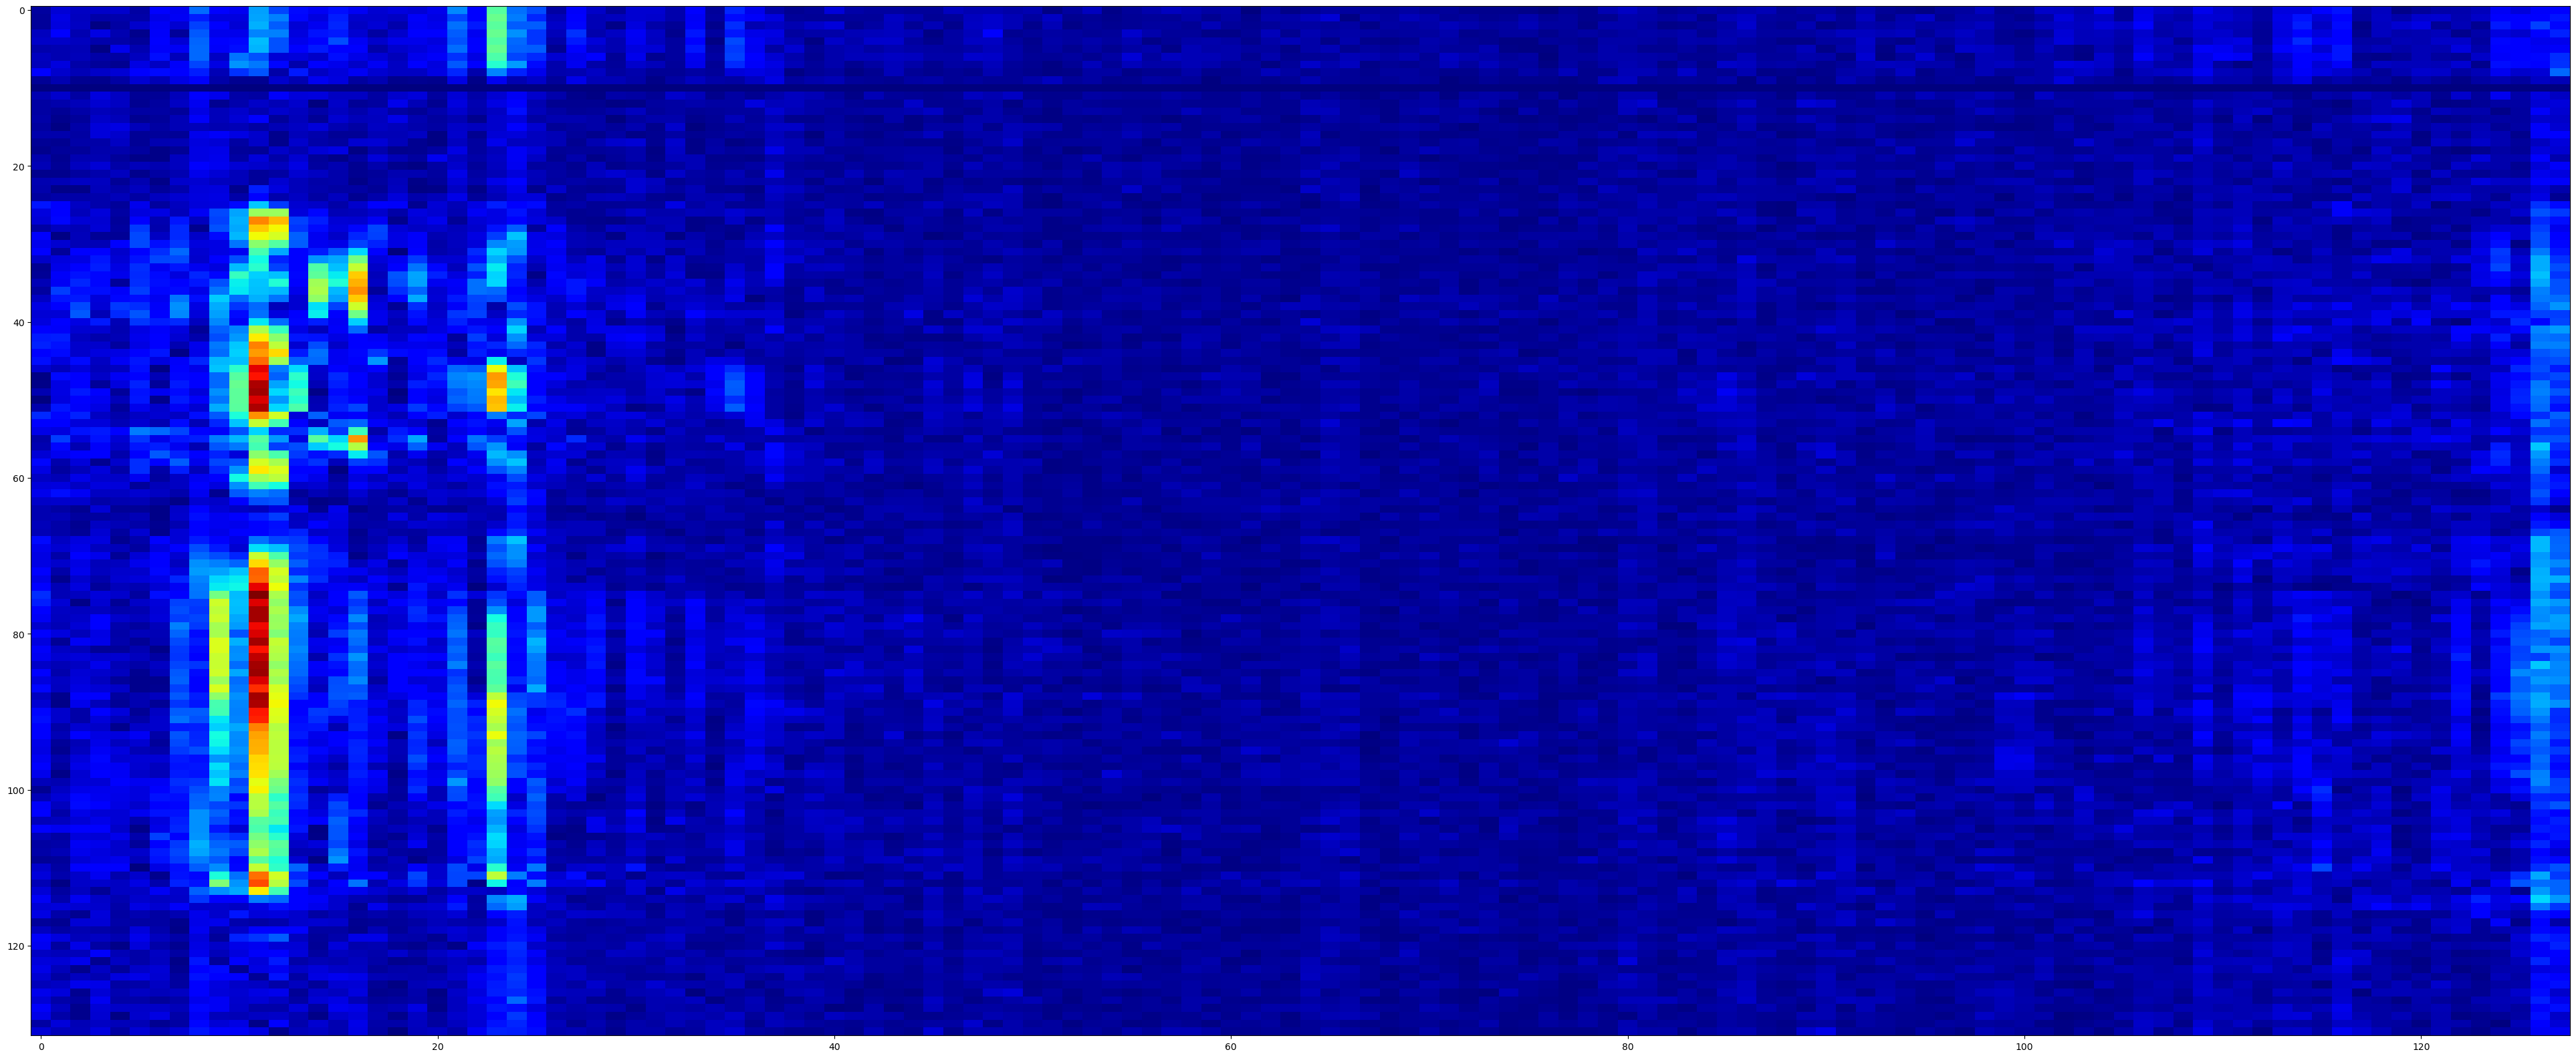

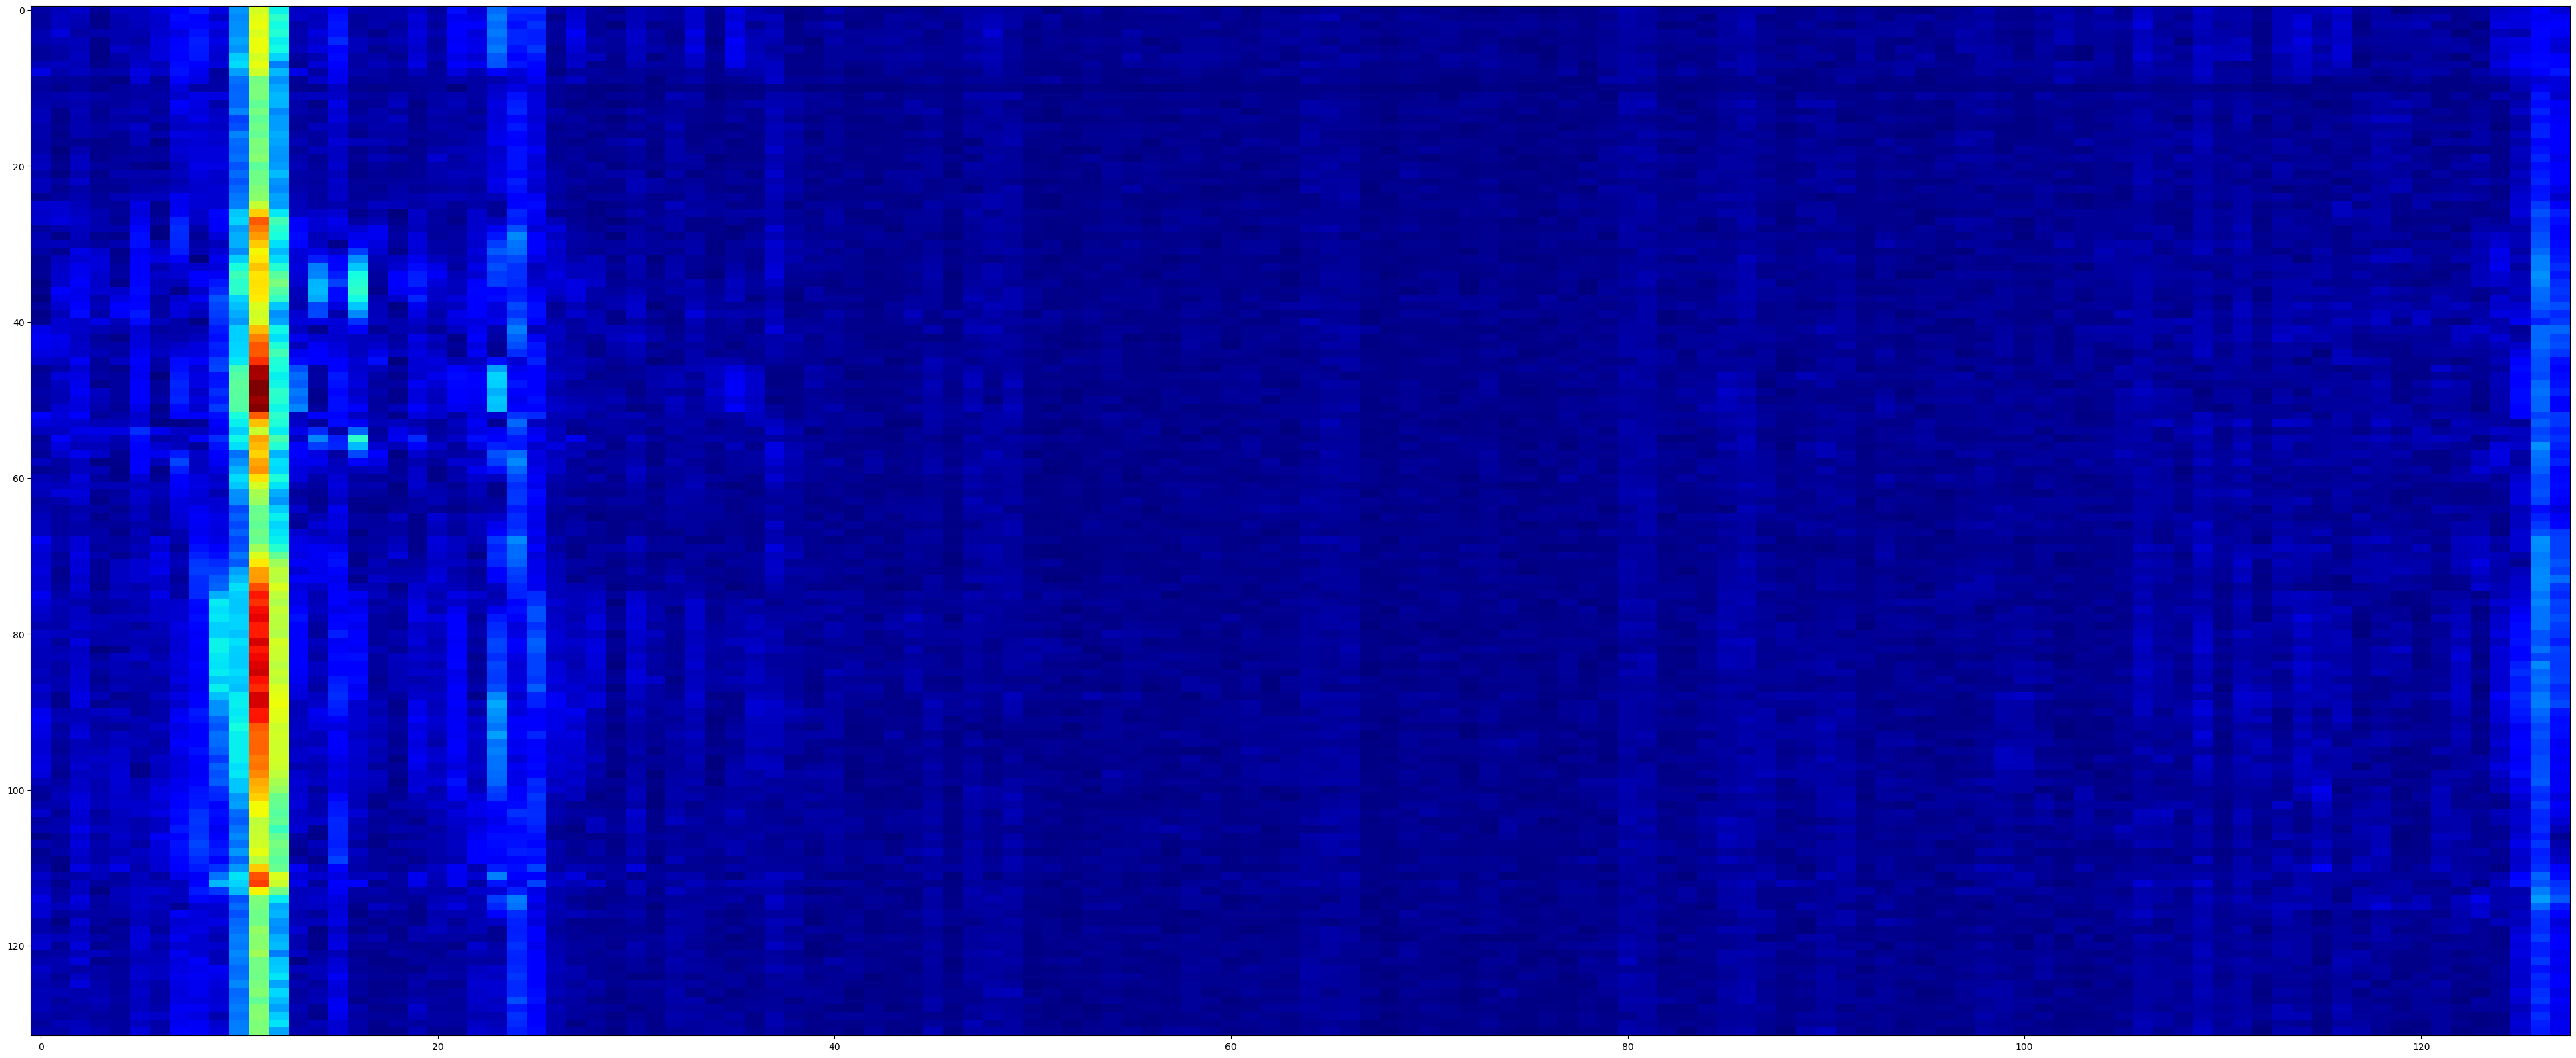

In [318]:
plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_np),cmap='jet',aspect='auto')

plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_cal_np),cmap='jet',aspect='auto')

plt.figure(figsize=[49,20])
plt.imshow(np.abs(s_cal_np_2),cmap='jet',aspect='auto')

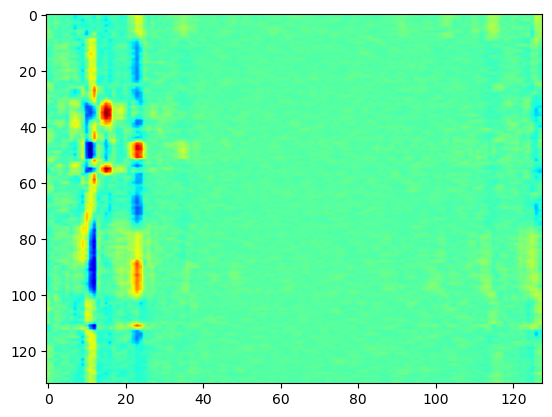

In [319]:
tmp = np.abs(s_np) - np.mean(np.abs(s_np),axis=0)
plt.imshow(tmp, cmap = 'jet', aspect='auto')

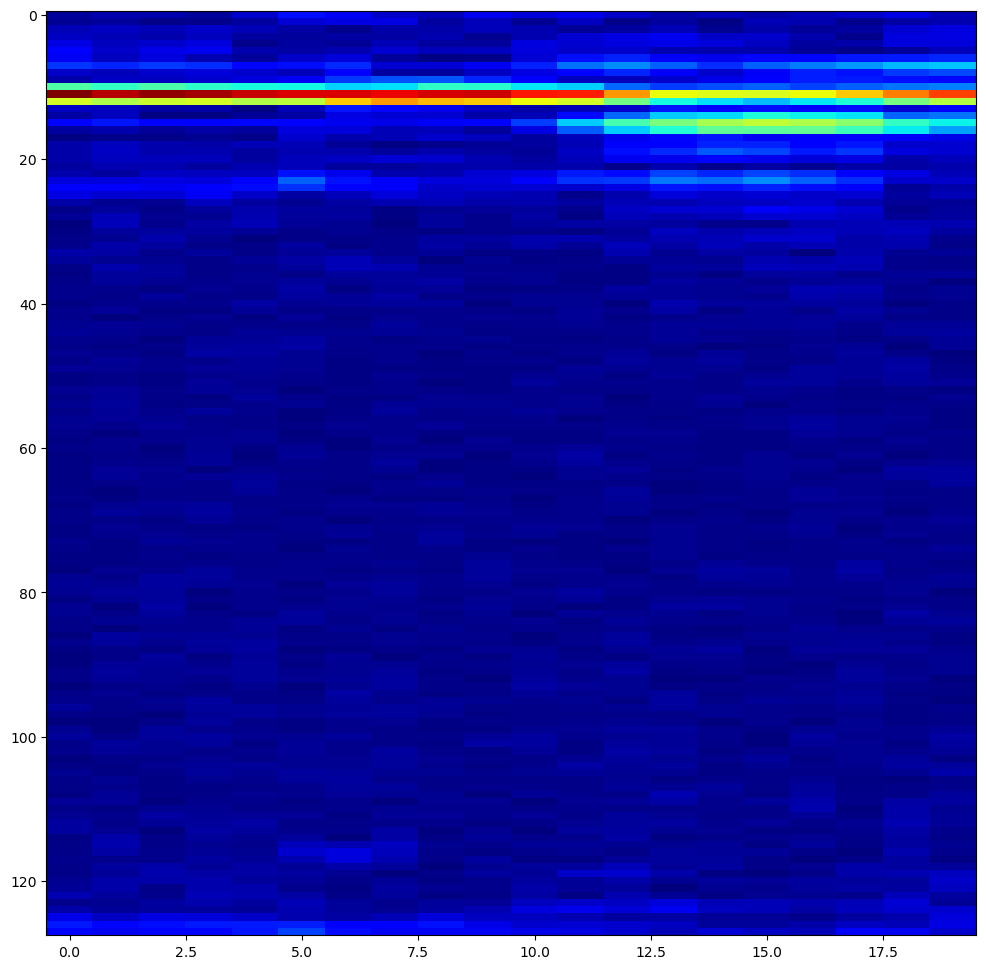

In [328]:
from sklearn import decomposition
M = np.transpose(np.abs(s_np[20:40]))
plt.figure(figsize=(12, 12))
plt.imshow(M, cmap='jet', aspect = 'auto')

In [329]:
u, s, v = decomposition.randomized_svd(np.abs(M), 1)

In [330]:
u.shape, s.shape, v.shape

((128, 1), (1,), (1, 20))

In [331]:
low_rank = u @ np.diag(s) @ v
low_rank.shape

(128, 20)

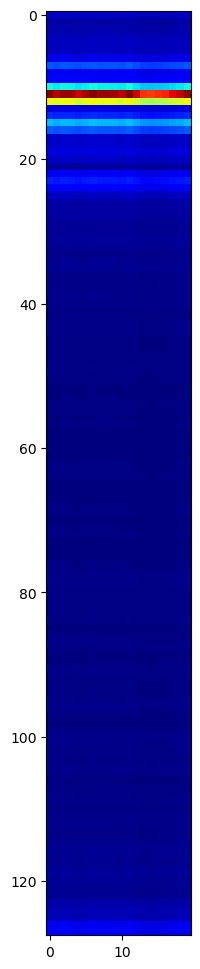

In [332]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='jet')

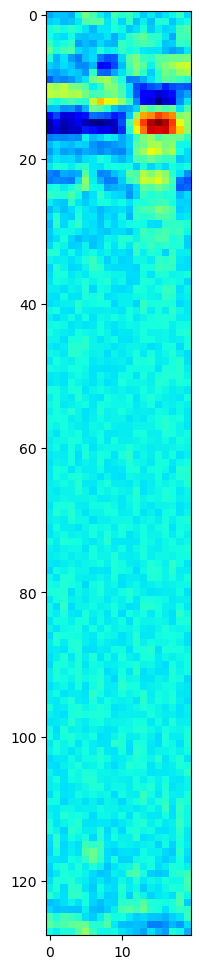

In [333]:
plt.figure(figsize=(12, 12))
plt.imshow(M-low_rank, cmap='jet')

In [146]:
tmp = np.abs(M[0:128])-low_rank[0:128]
M

(128, 1)

In [52]:
dims

(60, 80)